Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Load Data

In [2]:
news_cols = ['news_id', 'category', 'subcategory', 'title',
             'abstract', 'url', 'title_entities', 'abstract_entities']

news_df = pd.read_csv(
    '../data/MINDsmall_train/news.tsv',
    sep='\t',
    names=news_cols
)

beh_cols = ['impression_id', 'user_id', 'time', 'history', 'impressions']

behaviors_df = pd.read_csv(
    '../data/MINDsmall_train/behaviors.tsv',
    sep='\t',
    names=beh_cols
)

print(news_df.shape)
print(behaviors_df.shape)

(51282, 8)
(156965, 5)


Basic Stats

In [3]:
print("Total articles:", len(news_df))
print("Total users:", behaviors_df['user_id'].nunique())
print("Total impressions:", len(behaviors_df))

Total articles: 51282
Total users: 50000
Total impressions: 156965


Plot 1 - Category Distribution

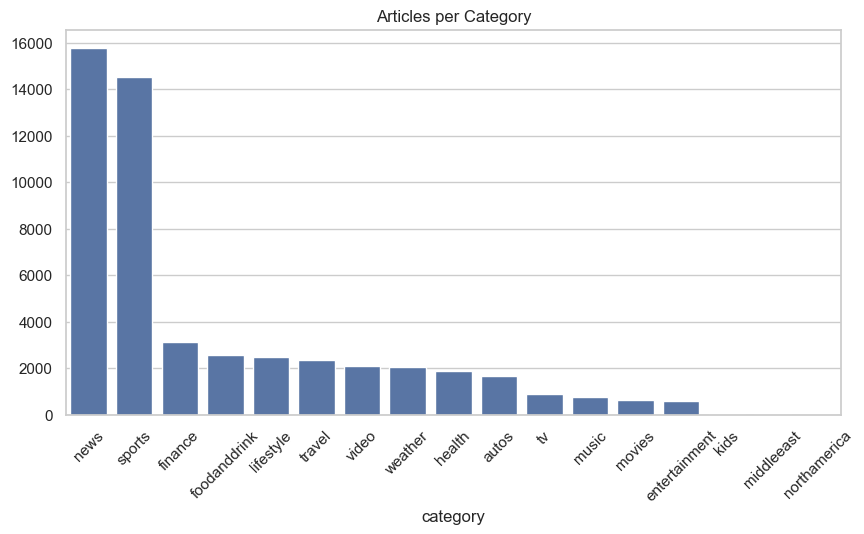

In [4]:
cat_counts = news_df['category'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=cat_counts.index, y=cat_counts.values)
plt.xticks(rotation=45)
plt.title("Articles per Category")
plt.show()

The dataset shows an uneven distribution of articles across categories, with categories such as news and support dominating the dataset. This imbalance may lead the model to favor more frequent categories, potentially reducing recommendation diversity.

Plot 2 - User Activity Distribution

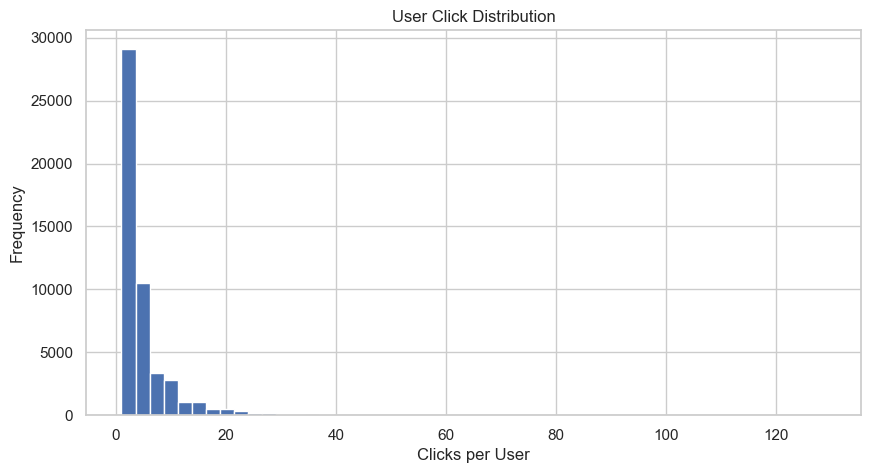

In [5]:
def count_clicks(impressions):
    if pd.isna(impressions):
        return 0
    return sum(1 for x in impressions.split() if x.endswith('-1'))

behaviors_df['n_clicks'] = behaviors_df['impressions'].apply(count_clicks)

user_clicks = behaviors_df.groupby('user_id')['n_clicks'].sum()

plt.figure(figsize=(10,5))
plt.hist(user_clicks, bins=50)
plt.title("User Click Distribution")
plt.xlabel("Clicks per User")
plt.ylabel("Frequency")
plt.show()

The distribution is highly skewed, where most users have very few interactions while a small number of users are highly active. This suggests a power-law behavior, which is common in recommendation systems and can make learning user preferences challenging.

Plot 3 - History Length

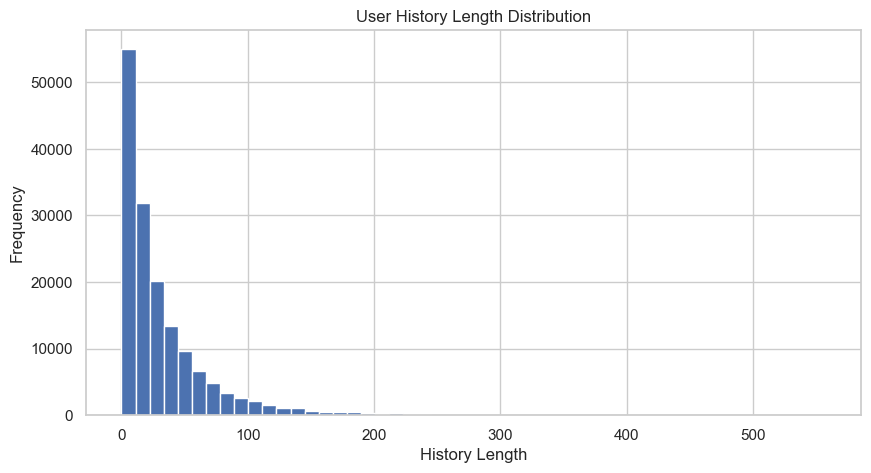

Mean: 32.53998662122129
Median: 19.0


In [6]:
def history_length(hist):
    if pd.isna(hist):
        return 0
    return len(hist.split())

behaviors_df['history_len'] = behaviors_df['history'].apply(history_length)

plt.figure(figsize=(10,5))
plt.hist(behaviors_df['history_len'], bins=50)
plt.title("User History Length Distribution")
plt.xlabel("History Length")
plt.ylabel("Frequency")
plt.show()

print("Mean:", behaviors_df['history_len'].mean())
print("Median:", behaviors_df['history_len'].median())

Plot 4 - Impression Size

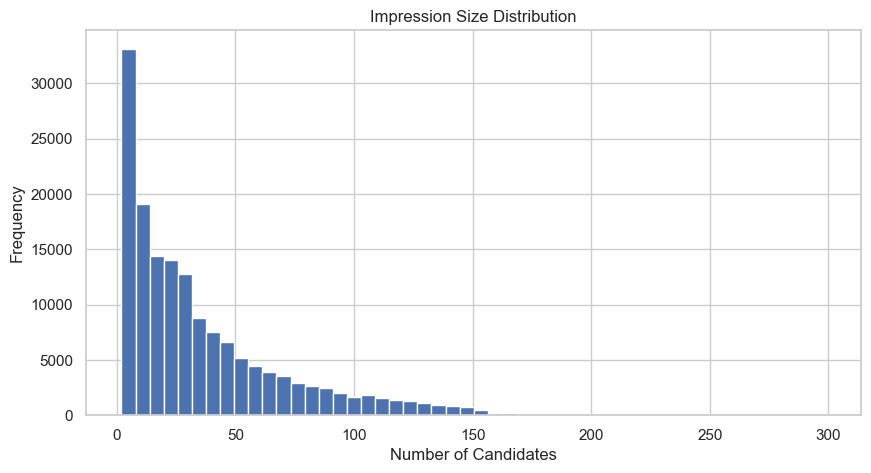

In [7]:
def impression_size(imp):
    if pd.isna(imp):
        return 0
    return len(imp.split())

behaviors_df['imp_size'] = behaviors_df['impressions'].apply(impression_size)

plt.figure(figsize=(10,5))
plt.hist(behaviors_df['imp_size'], bins=50)
plt.title("Impression Size Distribution")
plt.xlabel("Number of Candidates")
plt.ylabel("Frequency")
plt.show()

Plot 5 - CTR (Click Through Rate)

In [8]:
total_impressions = 0
total_clicks = 0

for imp in behaviors_df['impressions']:
    if pd.isna(imp):
        continue
    items = imp.split()
    total_impressions += len(items)
    total_clicks += sum(1 for x in items if x.endswith('-1'))

ctr = total_clicks / total_impressions
print("Overall CTR:", ctr)

Overall CTR: 0.040446010948338


Plot 6 - Title Length Distribution

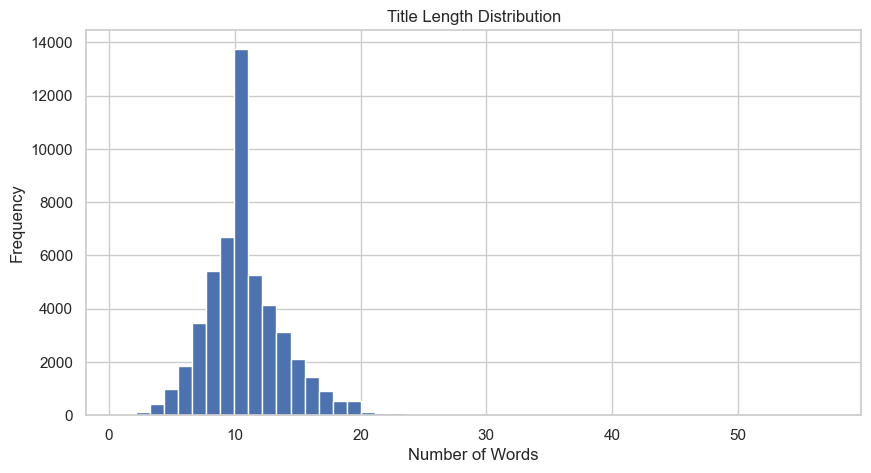

In [9]:
news_df['title_len'] = news_df['title'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
plt.hist(news_df['title_len'], bins=50)
plt.title("Title Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()